In [ ]:
# Instalar a biblioteca que puxa os dados direto do repositório UCI
!pip install ucimlrepo

# Importações principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Carregar os dois arquivos (tinto e branco)
url_tinto = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
url_branco = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

df_tinto = pd.read_csv(url_tinto, sep=";")
df_branco = pd.read_csv(url_branco, sep=";")

# Marcar a origem de cada um antes de juntar
df_tinto["tipo"] = "tinto"
df_branco["tipo"] = "branco"

# Juntar tudo num único DataFrame
df = pd.concat([df_tinto, df_branco], axis=0, ignore_index=True)

df.head()



print("Quantidade de linhas:", df.shape[0])
print("Quantidade de colunas:", df.shape[1])
print(df.columns.tolist())

Quantidade de linhas: 6497
Quantidade de colunas: 13
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'tipo']


In [ ]:
# Ver informações gerais (tipos de dado, valores não-nulos)
df.info()

# Ver estatísticas básicas de cada coluna numérica
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  tipo                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [ ]:
# 1. Remover duplicatas
print("Antes:", df.shape[0], "linhas")
df = df.drop_duplicates().reset_index(drop=True)
print("Depois:", df.shape[0], "linhas")

Antes: 6497 linhas
Depois: 5320 linhas


qualidade_faixa
médio    2323
ruim     1988
bom      1009
Name: count, dtype: int64


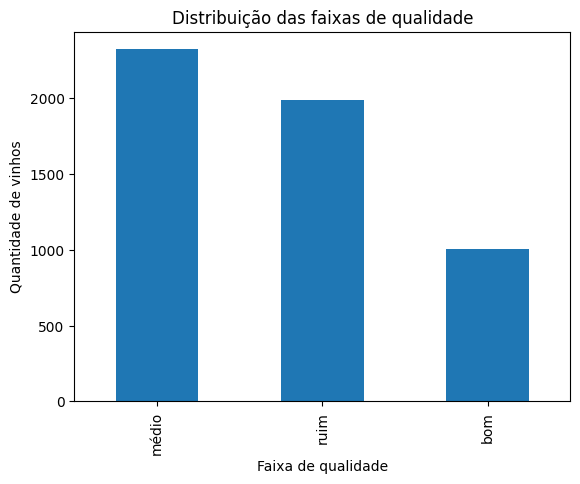

In [ ]:
# 2. Criar as 3 faixas de qualidade (ruim / médio / bom)
def classificar_qualidade(nota):
    if nota <= 5:
        return "ruim"
    elif nota == 6:
        return "médio"
    else:
        return "bom"

df['qualidade_faixa'] = df['quality'].apply(classificar_qualidade)

# Conferir como ficou a distribuição das faixas
print(df['qualidade_faixa'].value_counts())

# Gráfico
df['qualidade_faixa'].value_counts().plot(kind='bar')
plt.xlabel('Faixa de qualidade')
plt.ylabel('Quantidade de vinhos')
plt.title('Distribuição das faixas de qualidade')
plt.show()

In [ ]:
# Valores ausentes por coluna
print("Valores ausentes:")
print(df.isnull().sum())

# Quantidade de linhas duplicadas
print("\nLinhas duplicadas:", df.duplicated().sum())

Valores ausentes:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
tipo                    0
qualidade_faixa         0
dtype: int64

Linhas duplicadas: 0


quality
3      30
4     206
5    1752
6    2323
7     856
8     148
9       5
Name: count, dtype: int64


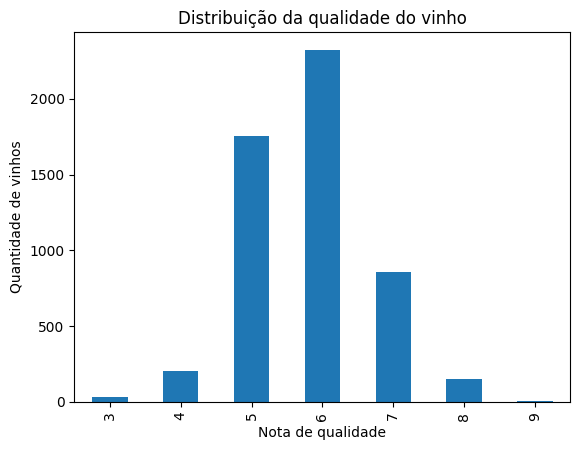

In [ ]:
# Contar quantos vinhos existem em cada nota
print(df['quality'].value_counts().sort_index())

# Gráfico de barras da distribuição
df['quality'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Nota de qualidade')
plt.ylabel('Quantidade de vinhos')
plt.title('Distribuição da qualidade do vinho')
plt.show()

In [ ]:
# Traduzir os nomes das colunas pro português
traducao = {
    'fixed acidity': 'acidez_fixa',
    'volatile acidity': 'acidez_volatil',
    'citric acid': 'acido_citrico',
    'residual sugar': 'acucar_residual',
    'chlorides': 'cloretos',
    'free sulfur dioxide': 'dioxido_enxofre_livre',
    'total sulfur dioxide': 'dioxido_enxofre_total',
    'density': 'densidade',
    'pH': 'pH',
    'sulphates': 'sulfatos',
    'alcohol': 'alcool',
    'quality': 'qualidade',
    'tipo': 'tipo',
    'qualidade_faixa': 'qualidade_faixa'
}

df = df.rename(columns=traducao)
df.head()

,acidez_fixa,acidez_volatil,acido_citrico,acucar_residual,cloretos,dioxido_enxofre_livre,dioxido_enxofre_total,densidade,pH,sulfatos,alcool,qualidade,tipo,qualidade_faixa
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,tinto,ruim
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,tinto,ruim
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,tinto,ruim
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,tinto,médio
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,tinto,ruim


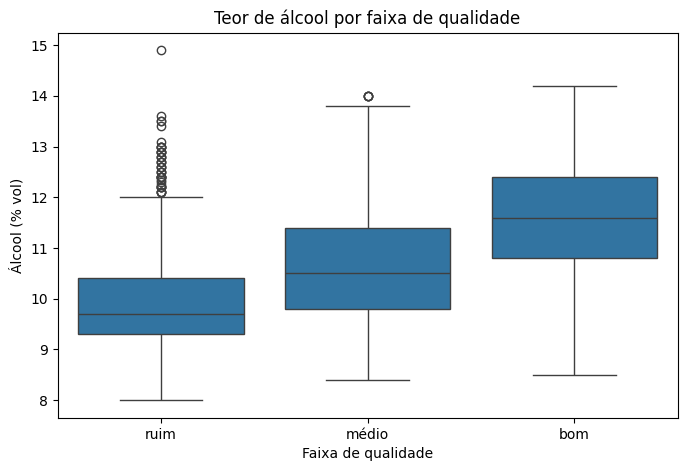

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='qualidade_faixa', y='alcool', order=['ruim', 'médio', 'bom'])
plt.title('Teor de álcool por faixa de qualidade')
plt.xlabel('Faixa de qualidade')
plt.ylabel('Álcool (% vol)')
plt.show()

In [ ]:
colunas_numericas = ['acidez_fixa', 'acidez_volatil', 'acido_citrico',
                      'acucar_residual', 'cloretos', 'dioxido_enxofre_livre',
                      'dioxido_enxofre_total', 'densidade', 'pH', 'sulfatos', 'alcool']

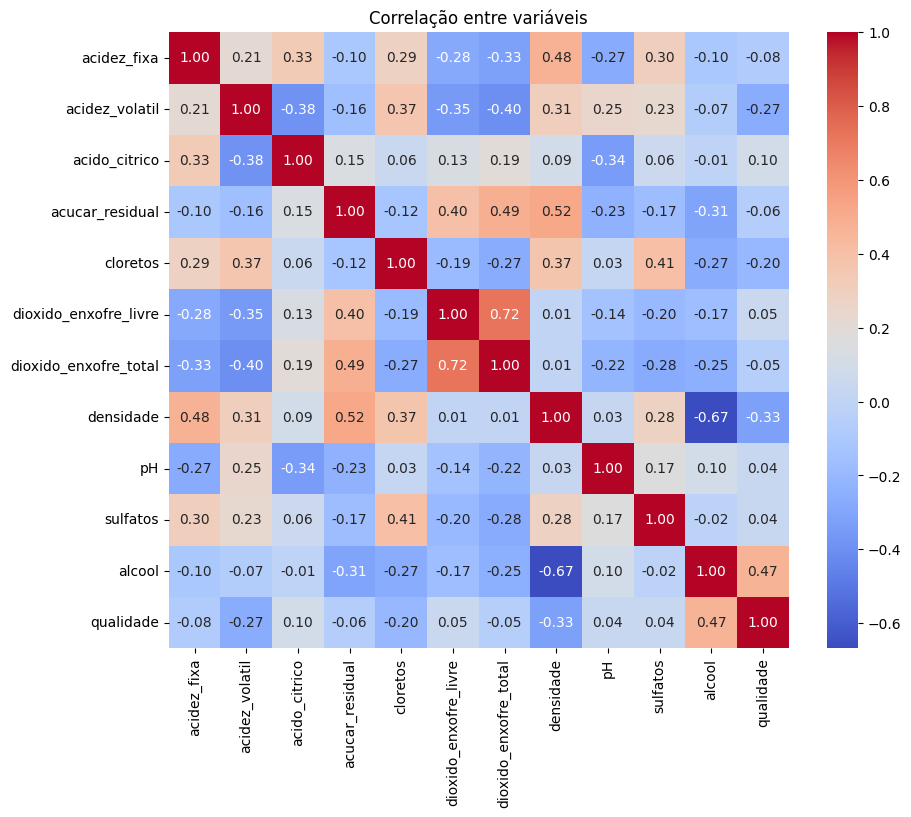

In [ ]:
plt.figure(figsize=(10,8))
correlacao = df[colunas_numericas + ['qualidade']].corr()
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlação entre variáveis')
plt.show()

In [ ]:
pd.crosstab(df['tipo'], df['qualidade_faixa'])

qualidade_faixa,bom,médio,ruim
tipo,,,
branco,825,1788,1348
tinto,184,535,640


In [ ]:
# Converter a variável categórica "tipo" para valores numéricos
df['tipo_numerico'] = df['tipo'].map({'tinto': 0, 'branco': 1})

from sklearn.model_selection import train_test_split

# Variáveis preditoras
X = df.drop(columns=["qualidade", "qualidade_faixa", "tipo"])

# Variável alvo
y = df["qualidade_faixa"]

# Separação dos conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
# Função para calcular os limites usando o método IQR
def limites_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

colunas_numericas = X_train.columns

# Aplicação do tratamento de outliers
for col in colunas_numericas:
    limite_inf, limite_sup = limites_iqr(X_train[col])

    X_train[col] = X_train[col].clip(limite_inf, limite_sup)
    X_test[col] = X_test[col].clip(limite_inf, limite_sup)

In [ ]:
# Padronização das variáveis
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
print("Treino")
print(y_train.value_counts(normalize=True))

print()

print("Teste")
print(y_test.value_counts(normalize=True))

Treino
qualidade_faixa
médio    0.436560
ruim     0.373825
bom      0.189615
Name: proportion, dtype: float64

Teste
qualidade_faixa
médio    0.43703
ruim     0.37312
bom      0.18985
Name: proportion, dtype: float64


Identificamos desbalanceamento entre as faixas; optamos por tratar isso na etapa de modelagem usando class_weight='balanced' nos modelos, em vez de reamostrar os dados.

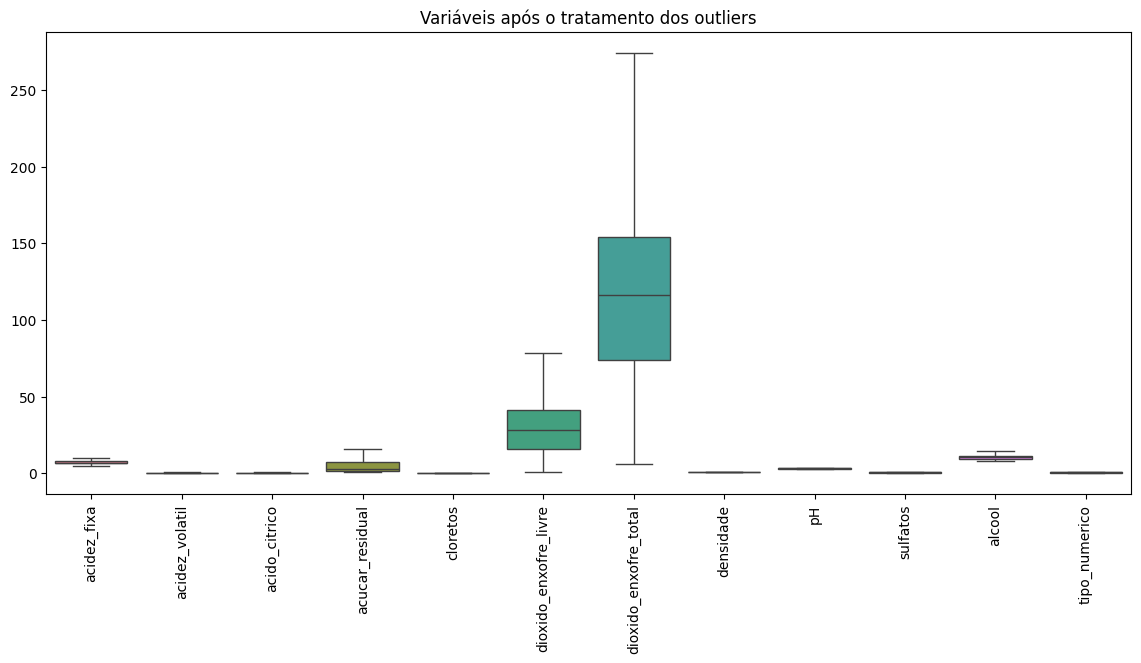

In [ ]:
plt.figure(figsize=(14,6))
sns.boxplot(data=X_train)
plt.xticks(rotation=90)
plt.title("Variáveis após o tratamento dos outliers")
plt.show()

In [ ]:
df.describe()

,acidez_fixa,acidez_volatil,acido_citrico,acucar_residual,cloretos,dioxido_enxofre_livre,dioxido_enxofre_total,densidade,pH,sulfatos,alcool,qualidade,tipo_numerico
count,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000
mean,7.215179,0.344130,0.318494,5.048477,0.056690,30.036654,114.109023,0.994535,3.224664,0.533357,10.549241,5.795677,0.744549
std,1.319671,0.168248,0.147157,4.500180,0.036863,17.805045,56.774223,0.002966,0.160379,0.149743,1.185933,0.879772,0.436155
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.240000,1.800000,0.038000,16.000000,74.000000,0.992200,3.110000,0.430000,9.500000,5.000000,0.000000
50%,7.000000,0.300000,0.310000,2.700000,0.047000,28.000000,116.000000,0.994650,3.210000,0.510000,10.400000,6.000000,1.000000
75%,7.700000,0.410000,0.400000,7.500000,0.066000,41.000000,153.250000,0.996770,3.330000,0.600000,11.400000,6.000000,1.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


Não foram identificadas inconsistências nos dados. As variáveis apresentaram valores dentro de faixas plausíveis para características físico-químicas de vinhos.

In [ ]:
correlacao["qualidade"].sort_values(key=abs, ascending=False)

,qualidade
qualidade,1.000000
alcool,0.469422
densidade,-0.326434
acidez_volatil,-0.265205
cloretos,-0.202137
acido_citrico,0.097954
acidez_fixa,-0.080092
acucar_residual,-0.056830
dioxido_enxofre_livre,0.054002
dioxido_enxofre_total,-0.050296


In [ ]:
print("Proporção das classes no treino:")
print(y_train.value_counts(normalize=True))

print()

print("Proporção das classes no teste:")
print(y_test.value_counts(normalize=True))

Proporção das classes no treino:
qualidade_faixa
médio    0.436560
ruim     0.373825
bom      0.189615
Name: proportion, dtype: float64

Proporção das classes no teste:
qualidade_faixa
médio    0.43703
ruim     0.37312
bom      0.18985
Name: proportion, dtype: float64
